In [1]:
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os
import cv2
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import torch
import matplotlib
from sklearn.decomposition import PCA

# Directory to save model checkpoints
save_dir = './checkpoints'
os.makedirs(save_dir, exist_ok=True), 

import torch
torch.cuda.empty_cache()  # Clear unused memory


VISUALIZE_PCA = True
VISUALIZE_TSNE = True
SHOW_GRADCAM_OUTPUTS = False
LOAD_MODEL_FROM_DISK = False #False #  # True
LOAD_FEATURES_FROM_DISK = False #False #  # True
EXPERIMENT_TYPE = "mixed" # white" # "black" "mixed"
MODEL_SAVING_PATH = None
batch_size = 64
learning_rate = 0.001
num_epochs = 20
#Save model after each epoch
def createFullPath(fileName, save_dir):
    os.makedirs(save_dir, exist_ok=True)
    return os.path.join(save_dir, EXPERIMENT_TYPE + " " + fileName)

def save_model(model, optimizer, avg_loss, test_accuracy, epoch, model_save_directory):
    os.makedirs("./saved_models", exist_ok=True)  # Create the directory if it doesn't exist
    checkpoint_path = os.path.join('./saved_models', f'{model_save_directory}.pth')
    torch.save({
        #'epoch': epoch , model_save_directory+ 1,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        #'loss': avg_loss,
        #'accuracy': test_accuracy
    }, checkpoint_path), model_save_directory

    print(f'Model saved at ./saved_models/{model_save_directory}')

In [2]:
#Active Conda Environment: condaPyProj311
conda_env = os.getenv("CONDA_DEFAULT_ENV")
print(f"dflt Conda Environment: {conda_env}")
# Get the path of the active conda environment
conda_env_path = os.getenv("CONDA_PREFIX")
if conda_env_path:
    # Extract the environment name from the path
    conda_env_name = os.path.basename(conda_env_path)
    print(f"Active Conda Environment: {conda_env_name}")
else:
    print("No active Conda environment")
from torchvision.datasets import ImageFolder
FIG_SIZE = (12,6)
output_directory = "./explained_images/"
os.makedirs(output_directory, exist_ok=True)  # Create the directory if it doesn't exist
class ImageFolderWithFilenames(ImageFolder):
    def __getitem__(self, index):
        # Get the original tuple of (image, label)
        original_tuple = super().__getitem__(index)
        # Get the image path and extract the filename
        path, _ = self.samples[index]
        filename = os.path.basename(path)
        # Return image, label, and filename
        return original_tuple[0], original_tuple[1], filename

dflt Conda Environment: condaPyProj311
Active Conda Environment: condaPyProj311


In [3]:
train_loss_list = []
test_accuracy_list = []
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')  # Prints 'cuda' if GPU is available, else 'cpu'
image_size = (480, 960)  # Image size
color_channel = 3 # only grayscale, so 1 channel is enough
# Define the transformations (resize, normalize, convert to tensor)
transform = transforms.Compose([
    transforms.Resize(image_size),  # Resize images to 960x480 pixels
    #transforms.Grayscale(num_output_channels=color_channel),  # Convert to grayscale (1 channel)
    transforms.ToTensor(),  # Convert the image to PyTorch tensor
    #transforms.Normalize((0.5), (0.5))  # Normalize the image between -1 and 1
])
if (EXPERIMENT_TYPE == "white"):
    MODEL_SAVING_PATH = "white_mode"
    train_dataset = ImageFolderWithFilenames(root='/home/zubair/Downloads/CNN Data/Training Images white', transform=transform)
    test_dataset = ImageFolderWithFilenames(root='/home/zubair/Downloads/CNN Data/Test Images White', transform=transform)
elif (EXPERIMENT_TYPE == "black"):
    MODEL_SAVING_PATH = "black_model"
    train_dataset = ImageFolderWithFilenames(root='/home/zubair/Downloads/CNN Data/Training Images Black', transform=transform)
    test_dataset = ImageFolderWithFilenames(root='/home/zubair/Downloads/CNN Data/Test Images Black', transform=transform)
else: # (EXPERIMENT_TYPE == "mixed_color_model"):
    MODEL_SAVING_PATH = "mixed_model"    
    train_dataset = ImageFolderWithFilenames(root='/home/zubair/Downloads/CNN Data/Training Images Combined', transform=transform)
    test_dataset = ImageFolderWithFilenames(root='/home/zubair/Downloads/CNN Data/Test Images Combined', transform=transform)

# DataLoader (to handle batch processing)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)

Using device: cuda


In [4]:
class SimpleCNNForGradCam(nn.Module):
    def __init__(self):
        super(SimpleCNNForGradCam, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=color_channel, out_channels=16, kernel_size=3, stride=1, padding=1, device=device),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride=1, padding=1, device=device),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1, device=device),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1, device=device),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1, device=device),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(self._get_conv_output_size(image_size), 512),
            nn.ReLU(),
            
            nn.Linear(512, 1024),
            nn.ReLU(),
            
            nn.Linear(1024, len(train_dataset.classes))
        )
        # Placeholder for feature maps and gradients
        self.feature_maps = None
        self.gradients = None
    def forward(self, x):
        x = self.conv_layers(x)
        self.feature_maps = x  # Store feature maps
        x.register_hook(self.activations_hook)  # Register hook to store gradients
        x = x.reshape(x.size(0), -1)
        x = self.fc_layers(x)
        return x
    def _get_conv_output_size(self, img_size):
        with torch.no_grad():
            dummy_input = torch.ones(1, color_channel, *img_size).to(device)
            x = self.conv_layers(dummy_input)
            return x.numel()
    def activations_hook(self, grad):
        self.gradients = grad  # Store gradients
    def get_activations_gradient(self):
        return self.gradients
    def get_activations(self, x):
        return self.conv_layers(x)
    #for tsne experiment
    def forward_features(self, x):
        x = self.conv_layers(x)  # Get feature output from conv layers
        x = x.reshape(x.size(0), -1)  # Flatten
        return x

In [5]:
# Modify the training function to save loss, accuracy, and model
def train_model_ForGradCam(model, train_loader, test_loader, criterion, optimizer, num_epochs, device):
    model.train()  # Set the model to training mode
    for epoch in range(num_epochs):
        running_loss = 0.0
        # Training loop
        for images, labels, filenames in train_loader:
            images, labels = images.to(device), labels.to(device)  # Move data to the GPU/CPU
            optimizer.zero_grad()  # Zero the gradients
            outputs = model(images)  # Forward pass
            loss = criterion(outputs, labels)  # Compute the loss
            loss.backward()  # Backpropagation
            optimizer.step()  # Update the weights
            running_loss += loss.item()
        # Average loss for the epoch
        avg_loss = running_loss / len(train_loader)
        train_loss_list.append(avg_loss)
        print(f'Epoch [{epoch + 1}/{num_epochs}], Train Loss: {avg_loss:.4f}')
        # Test accuracy at the end of each epoch
        test_accuracy = test_model(model, test_loader, device)
        test_accuracy_list.append(test_accuracy)
        # save_model(model, optimizer, avg_loss, test_accuracy, epoch);
    return train_loss_list, test_accuracy_list

# Modify the test function to return accuracy
def test_model(model, test_loader, device):
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0

    # with torch.no_grad():  # No need to track gradients for testing
    for images, labels, fileNames in test_loader:
        images, labels = images.to(device), labels.to(device)  # Move data to the GPU/CPU
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracy of the model on the test images: {accuracy:.2f}%')
    return accuracy


In [6]:
# Function to plot the loss and accuracy
def plot_metrics(train_loss_list, test_accuracy_list):
    epochs = range(1, len(train_loss_list) + 1)
    # Plot Loss
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_loss_list, '-o', label='Training Loss')
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, test_accuracy_list, '-o', label='Test Accuracy')
    plt.title('Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()

    plt.tight_layout()
    plt.savefig(os.path.join(output_directory, f"{EXPERIMENT_TYPE} metric.png"), dpi=300)
    plt.show()    

In [7]:
def save_metrics_to_disk(train_loss_list, test_accuracy_list, train_loss_filename, train_accuracy_filename):
    np.save(createFullPath(train_loss_filename, 'saved_metrics'), train_loss_list)  # Save train_loss_list as numpy array
    np.save(createFullPath(train_accuracy_filename, 'saved_metrics'), test_accuracy_list)  # Save test_accuracy_list as numpy array

In [ ]:
modelForGradCam = None
criterionForGradCam = None
optimizerForGradCam = None
if not LOAD_MODEL_FROM_DISK:
    modelForGradCam = SimpleCNNForGradCam().to(device)  # Move the model to the GPU/CPU
    criterionForGradCam = nn.CrossEntropyLoss()  # Cross entropy loss for multi-class classification
    optimizerForGradCam = optim.Adam(modelForGradCam.parameters(), lr=learning_rate)
    train_loss_list, test_accuracy_list = train_model_ForGradCam(modelForGradCam, train_loader, test_loader, criterionForGradCam, optimizerForGradCam, num_epochs, device)
    save_model(modelForGradCam, optimizerForGradCam, 0, 0, 0, MODEL_SAVING_PATH);
    print( "model trained now")
    plot_metrics(train_loss_list, test_accuracy_list)
    save_metrics_to_disk(train_loss_list, test_accuracy_list, "trainLoss", "testAccuracy")
    
elif LOAD_MODEL_FROM_DISK:
    modelForGradCam = SimpleCNNForGradCam()  # Ensure this matches your saved model
    checkpoint_path = f"./saved_models/{MODEL_SAVING_PATH}.pth"
    checkpoint = torch.load(checkpoint_path)
    modelForGradCam.load_state_dict(checkpoint["model_state_dict"])
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    modelForGradCam.to(device)
    print( "model fetched from ", )

Epoch [1/20], Train Loss: 0.4736
Accuracy of the model on the test images: 83.68%


In [19]:
def grad_cam(model, image, target_class):
    model.eval()
    image = image.unsqueeze(0).to(device)  # Add batch dimension and move to device
    # Forward pass
    output = model(image)
    model.zero_grad()
    # Backward pass for the target class
    one_hot = torch.zeros_like(output)
    one_hot[0][target_class] = 1
    output.backward(gradient=one_hot)
    # Get gradients and feature maps
    gradients = model.get_activations_gradient()
    feature_maps = model.feature_maps
    # Pool the gradients and weight the feature maps
    pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])
    for i in range(feature_maps.size(1)):
        feature_maps[:, i, :, :] *= pooled_gradients[i]
    # Generate the heatmap
    heatmap = torch.mean(feature_maps, dim=1).squeeze()
    heatmap = torch.relu(heatmap)  # Apply ReLU to the heatmap
    heatmap /= torch.max(heatmap)  # Normalize the heatmap
    return heatmap.detach().cpu().numpy()

In [20]:
def visualize_grad_cam(image, heatmap, label, filename):
    # Resize heatmap to match the image size
    heatmap = cv2.resize(heatmap, (image.shape[2], image.shape[1]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    # Superimpose the heatmap on the image
    superimposed_img = heatmap * 0.4 + image.squeeze().permute(1, 2, 0).cpu().numpy() * 255
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)
    plt.figure(figsize=(24,12))  # Adjust aspect ratio (12:6 = 960:480 for 80 dpi)
    plt.title(f"Grad-CAM Heatmap: truelabel: {label}, predictedLabel: dont care, fileName: {filename}")
    # Display the result
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.savefig(os.path.join(output_directory, f"gradCam_New_{filename}.png"), dpi=300)
    plt.show()

In [21]:
if (SHOW_GRADCAM_OUTPUTS):
    images, labels, filenames = next(iter(test_loader))
    for image,label, fielname in zip(images, labels, filenames):
        heatmap = grad_cam(modelForGradCam, image, label.item())
        visualize_grad_cam(image, heatmap, label, fielname)

In [22]:
def return_grad_cam(image, heatmap, label, filename):
    # Resize heatmap to match the image size
    heatmap = cv2.resize(heatmap, (image.shape[2], image.shape[1]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    # Superimpose the heatmap on the image
    superimposed_img = heatmap * 0.4 + image.squeeze().permute(1, 2, 0).cpu().numpy() * 255
    superimposed_img = np.clip(superimposed_img, 0, 255).astype(np.uint8)
    return superimposed_img
    
def extract_features_from_model(dataloader, model, device):
    model.eval()
    all_features = []
    all_labels = []
    all_filenames = []
    all_images = []  # To store original images
    with torch.no_grad():
        for images, labels, filenames in dataloader:
            images, labels = images.to(device), labels.to(device)
            features = model.forward_features(images)
            features = features.view(features.size(0), -1)  # Flatten to [batch_size, channels * height * width]
            all_features.append(features.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
            all_filenames.extend(filenames)
            all_images.append(images.cpu())  # Store images on CPU
    all_features = np.concatenate(all_features, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    all_images = torch.cat(all_images, dim=0)
    return all_features, all_labels, all_filenames, all_images
print(matplotlib.get_backend())  # Check current backend
# Switch to an interactive backend if necessary
#matplotlib.use('Qt5Agg')  # Or 'Qt5Agg', 'MacOSX' depending on your OS
features, labels, filenames, images = None, None, None, None

module://matplotlib_inline.backend_inline


In [23]:
def save_features_to_disk(features, labels, filenames, images, feature_file, label_file, filename_file, image_file):
    # Save features and labels as numpy arrays    
    np.save(createFullPath(feature_file, 'saved_features'), features)  # Save features as a numpy array
    np.save(createFullPath(label_file, 'saved_features'), labels)      # Save labels as a numpy array
    np.save(createFullPath(filename_file, 'saved_features'), filenames)  # Save filenames as a numpy array
    # Save images as torch tensor (you can also use .png or .jpeg for individual image files if needed)
    torch.save(images, createFullPath(image_file, 'saved_features'))  # Save images as a tensor to a .pt file
    
def load_features_from_disk(feature_file, label_file, filename_file, image_file):
    # Load features and labels from numpy files
    features = np.load(createFullPath( feature_file, 'saved_features'))  # Load features
    labels = np.load(createFullPath( label_file, 'saved_features'))      # Load labels
    filenames = np.load(createFullPath( filename_file, 'saved_features'))  # Load filenames
    # Load images from torch file
    images = torch.load(createFullPath( image_file, 'saved_features'))  # Load images as a tensor
    return features, labels, filenames, images
  
# Example usage:
if  not (LOAD_FEATURES_FROM_DISK):
    features, labels, filenames, images = extract_features_from_model(train_loader, modelForGradCam, device)
    save_dir = 'saved_features'
    os.makedirs(save_dir, exist_ok=True)
    save_features_to_disk(features, labels, filenames, images, 'features.npy', 'labels.npy', 'filenames.npy', 'images.pt')
else:
    features, labels, filenames, images = load_features_from_disk('features.npy', 'labels.npy', 'filenames.npy', 'images.pt')

module://matplotlib_inline.backend_inline


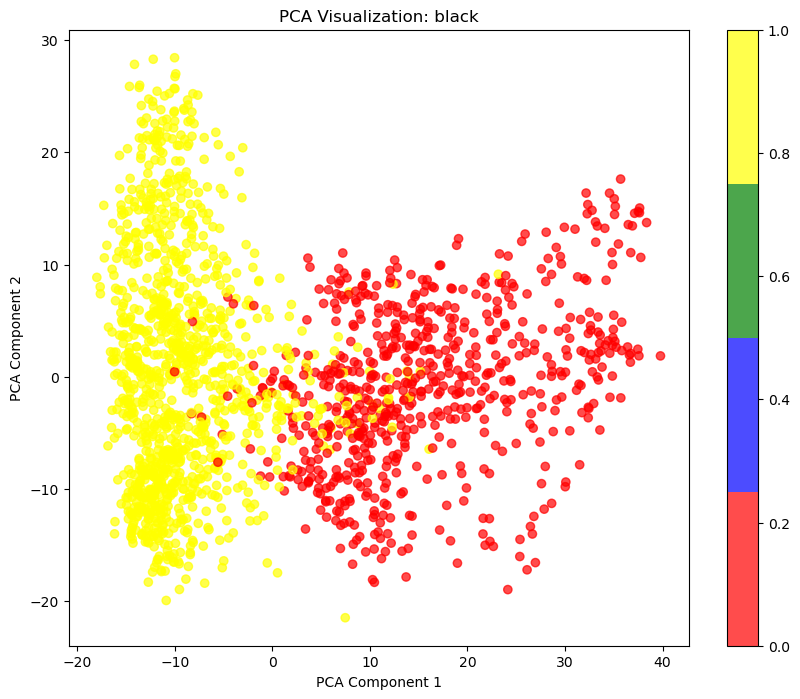

In [24]:
def visualize_pca(features, labels, filenames, images, exp_type):
    pca = PCA(n_components=2)  # Reduce to 2D
    reduced_features = pca.fit_transform(features)
    fig, ax = plt.subplots(figsize=(10, 8))
    cmap = ListedColormap(['red', 'blue', 'green', 'yellow'])
    scatter = ax.scatter(reduced_features[:, 0], reduced_features[:, 1], c=labels, cmap=cmap, alpha=0.7)
    plt.colorbar(scatter)
    plt.title(f'PCA Visualization: {exp_type}')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')
    #matplotlib.use('Qt5Agg')  # Or 'Qt5Agg', 'MacOSX' depending on your OS
    print(matplotlib.get_backend()) 

    # Function to display original image on click
    def on_click(event):
        if event.inaxes == ax:
            distances = ((reduced_features[:, 0] - event.xdata) ** 2 +
                         (reduced_features[:, 1] - event.ydata) ** 2)
            index = distances.argmin()
            # Display the original image
            clicked_image = images[index].permute(1, 2, 0).numpy()  # Convert to (H, W, C)
            plt.ion()  # Enable interactive mode
            plt.figure(figsize=(4, 4))
            plt.imshow(clicked_image)
            plt.title(f"Filename: {filenames[index]}, Label: {labels[index]}")
            plt.axis('off')
            plt.show()
    fig.canvas.mpl_connect('button_press_event', on_click)
    plt.savefig(os.path.join(output_directory, f"PCA-{EXPERIMENT_TYPE}.png"), dpi=300)
    plt.show()
# Call the function with your extracted features
if(VISUALIZE_PCA):
    visualize_pca(features, labels, filenames, images, EXPERIMENT_TYPE)

In [29]:

def visualize_tsne(features, labels, filenames, images, exp_type):
    tsne = TSNE(n_components=2, random_state=42)
    reduced_features = tsne.fit_transform(features)
    fig, ax = plt.subplots(figsize=(10, 8))
    cmap = ListedColormap(['red', 'blue', 'green', 'yellow'])
    scatter = ax.scatter(reduced_features[:, 0], reduced_features[:, 1], c=labels, cmap=cmap, alpha=0.7)
    matplotlib.use('TkAgg')  # Or 'Qt5Agg', 'MacOSX' depending on your OS
    print(matplotlib.get_backend()) 
    plt.colorbar(scatter)
    plt.title(f't-SNE Visualization: {exp_type}')
    plt.xlabel('t-SNE Component 1')
    plt.ylabel('t-SNE Component 2')
    # Function to display original image on click
    def on_click(event):
        if event.inaxes == ax:
            distances = ((reduced_features[:, 0] - event.xdata) ** 2 +
                         (reduced_features[:, 1] - event.ydata) ** 2)
            index = distances.argmin()
            # Display the original image
            clicked_image = images[index].permute(1, 2, 0).numpy()  # Convert to (H, W, C)
            # now grad_cam()
            clicked_imageToDevice = torch.tensor(clicked_image).permute(2, 0, 1).to(device) #gradcam needs c,h,w
            heatmap = grad_cam(modelForGradCam, clicked_imageToDevice, None) #fix image shapes here
            # Visualize Grad-CAM result
            gradcamImage = return_grad_cam(clicked_imageToDevice, heatmap, "None", filenames[index])
            plt.ion()  # Enable interactive mode
            fig, axes = plt.subplots(1, 2, figsize=(24, 12))  # Two side-by-side plots
            # Show original image
            axes[0].imshow(clicked_image)
            axes[0].set_title(f"Original: {filenames[index]}, TrueLabel: {labels[index]}")
            axes[0].axis('off')
            # Show Grad-CAM image
            axes[1].imshow(gradcamImage)
            axes[1].set_title(f"Grad-CAM: {filenames[index]}, TrueLabel: {labels[index]}")
            axes[1].axis('off')
            plt.savefig(os.path.join(output_directory, f"tsne exp-{EXPERIMENT_TYPE} {filenames[index]}"), dpi=300)
            plt.show()
    fig.canvas.mpl_connect('button_press_event', on_click)
    plt.savefig(os.path.join(output_directory, f"tsne-{EXPERIMENT_TYPE}.png"), dpi=300)
    plt.show(block=True)
if (VISUALIZE_TSNE):
    visualize_tsne(features, labels, filenames, images, EXPERIMENT_TYPE)

TkAgg
TkAgg
